### Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.over_sampling import BorderlineSMOTE, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from scipy import stats
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

### Load the Data

In [ ]:
# Load the uploaded label file
df = pd.read_csv("gz2_hart16.csv")

# Show structure of labels
df.info(5)

<class 'pandas.DataFrame'>
RangeIndex: 239695 entries, 0 to 239694
Data columns (total 231 columns):
 #    Column                                                         Dtype  
---   ------                                                         -----  
 0    dr7objid                                                       int64  
 1    ra                                                             float64
 2    dec                                                            float64
 3    rastring                                                       str    
 4    decstring                                                      str    
 5    sample                                                         str    
 6    gz2_class                                                      str    
 7    total_classifications                                          int64  
 8    total_votes                                                    int64  
 9    t01_smooth_or_features_a01_smooth_count       

In [27]:
df.head()

,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0


In [ ]:
drop_cols = [c for c in df.columns if
             ('_count' in c) or
             ('_weight' in c) or
             ('_flag' in c) or
             ('_fraction' in c and 'debiased' not in c)]

drop_cols += ['dr7objid','ra','dec','rastring','decstring','sample','gz2_class']

df_clean = df.drop(columns=drop_cols)

print("Dataset shape setelah pembersihan:", df_clean.shape)
print(df_clean.head())

Dataset shape awal: (239695, 231)
             dr7objid          ra        dec     rastring    decstring  \
0  587732591714893851  179.042984  60.522518  11:56:10.32  +60:31:21.1   
1  588009368545984617  135.084396  52.494240  09:00:20.26  +52:29:39.3   
2  587732484359913515  183.371979  50.741508  12:13:29.27  +50:44:29.4   
3  587741723357282317  186.251953  28.558598  12:25:00.47  +28:33:31.0   
4  587738410866966577  161.086395  14.084465  10:44:20.73  +14:05:04.1   

     sample gz2_class  total_classifications  total_votes  \
0  original      Sc+t                     45          342   
1  original      Sb+t                     42          332   
2  original        Ei                     36          125   
3  original      Sc+t                     28          218   
4  original        Er                     43          151   

   t01_smooth_or_features_a01_smooth_count  ...  \
0                                        0  ...   
1                                        1  ...   
2

In [29]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 239695 entries, 0 to 239694
Data columns (total 39 columns):
 #   Column                                                Non-Null Count   Dtype  
---  ------                                                --------------   -----  
 0   total_classifications                                 239695 non-null  int64  
 1   total_votes                                           239695 non-null  int64  
 2   t01_smooth_or_features_a01_smooth_debiased            239695 non-null  float64
 3   t01_smooth_or_features_a02_features_or_disk_debiased  239695 non-null  float64
 4   t01_smooth_or_features_a03_star_or_artifact_debiased  239695 non-null  float64
 5   t02_edgeon_a04_yes_debiased                           239695 non-null  float64
 6   t02_edgeon_a05_no_debiased                            239401 non-null  float64
 7   t03_bar_a06_bar_debiased                              239695 non-null  float64
 8   t03_bar_a07_no_bar_debiased                           2

In [30]:
smooth = df_clean["t01_smooth_or_features_a01_smooth_debiased"]
disk   = df_clean["t01_smooth_or_features_a02_features_or_disk_debiased"]
spiral = df_clean["t04_spiral_a08_spiral_debiased"]

conditions = [
    (smooth > 0.6),                         # Non-spiral
    (disk > 0.5) & (spiral > 0.5)           # Spiral
]

choices = [1, 2]

df_clean["target"] = np.select(conditions, choices, default=0)

In [32]:
df_clean.dropna(inplace=True)
df_clean.info()

<class 'pandas.DataFrame'>
Index: 239389 entries, 0 to 239694
Data columns (total 40 columns):
 #   Column                                                Non-Null Count   Dtype  
---  ------                                                --------------   -----  
 0   total_classifications                                 239389 non-null  int64  
 1   total_votes                                           239389 non-null  int64  
 2   t01_smooth_or_features_a01_smooth_debiased            239389 non-null  float64
 3   t01_smooth_or_features_a02_features_or_disk_debiased  239389 non-null  float64
 4   t01_smooth_or_features_a03_star_or_artifact_debiased  239389 non-null  float64
 5   t02_edgeon_a04_yes_debiased                           239389 non-null  float64
 6   t02_edgeon_a05_no_debiased                            239389 non-null  float64
 7   t03_bar_a06_bar_debiased                              239389 non-null  float64
 8   t03_bar_a07_no_bar_debiased                           239389

In [ ]:
categorical_features = [
    col for col in df.select_dtypes(include=["int64"]).columns
    if col != "TARGET"
]

if categorical_features:
    # Create encoder
    encoder = OneHotEncoder(sparse_output=False, drop='first')

    # Fit and transform categorical features
    encoded_array = encoder.fit_transform(df[categorical_features])

    # Get feature names
    encoded_feature_names = encoder.get_feature_names_out(categorical_features)

    # Create DataFrame for encoded features
    encoded_df = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=df.index)

    # Drop original categorical columns and add encoded ones
    df_encoded = df.drop(columns=categorical_features)
    df_encoded = pd.concat([df_encoded, encoded_df], axis=1)
else:
    df_encoded = df.copy()
    encoded_feature_names = []

print(f"\nOriginal shape: {df.shape}")
print(f"After One Hot Encoding shape: {df_encoded.shape}")

X = df_encoded.drop(columns=["TARGET"])
y = df_encoded["TARGET"]


# Normalization

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Combine back with target
df_final = X_scaled.copy()
df_final["TARGET"] = y.values
df_final


Original shape: (239389, 40)
After One Hot Encoding shape: (239389, 577)


,t01_smooth_or_features_a01_smooth_debiased,t01_smooth_or_features_a02_features_or_disk_debiased,t01_smooth_or_features_a03_star_or_artifact_debiased,t02_edgeon_a04_yes_debiased,t02_edgeon_a05_no_debiased,t03_bar_a06_bar_debiased,t03_bar_a07_no_bar_debiased,t04_spiral_a08_spiral_debiased,t04_spiral_a09_no_spiral_debiased,t05_bulge_prominence_a10_no_bulge_debiased,...,total_votes_521,total_votes_527,total_votes_528,total_votes_534,total_votes_536,total_votes_537,total_votes_539,total_votes_584,total_votes_604,target
0,0.000,0.988,0.014252,0.047681,0.953848,0.025,0.975305,1.000000,0.000000,0.050,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,0.024,0.976,0.000000,0.000000,1.000000,0.080,0.920038,1.000000,0.000000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0.780,0.139,0.096200,0.000000,1.000000,0.400,0.600190,0.000000,1.000000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.036,0.964,0.000000,0.036974,0.963112,0.038,0.962028,0.962366,0.038012,0.077,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,0.767,0.186,0.055819,0.125182,0.878825,0.000,1.000000,0.000000,1.000000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239384,0.823,0.174,0.003563,0.857000,0.143000,0.000,1.000000,0.000000,1.000000,1.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
239385,0.541,0.263,0.233967,0.000000,1.000000,0.000,1.000000,0.000000,1.000000,0.750,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
239386,0.789,0.156,0.065321,0.000000,1.000000,0.143,0.857000,0.286000,0.714000,0.857,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
239387,0.531,0.278,0.226841,0.000000,1.000000,0.000,1.000000,0.076000,0.924000,0.612,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
# Preparation data using df_final
# Split features and target from df_final
X = df_final.drop('target_class', axis=1)
y = df_final['target_class']

print("=" * 60)
print("Data before Resampling")
print("=" * 60)
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print("\nClass distribution before Resampling:")
print(y.value_counts().sort_index())
for cls in sorted(y.unique()):
    count = (y == cls).sum()
    print(f"  Class {cls}: {count} samples ({count/len(y)*100:.2f}%)")

# Calculate class weights from original distribution
classes = np.unique(y)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)
class_weight_dict = dict(zip(classes, class_weights))

print("\n" + "=" * 60)
print("Class Weights")
print("=" * 60)
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")

# Resampling with undersampling or oversampling, choose one 

# Undersampling
nearmiss = NearMiss(
   version=1,  
    n_neighbors=3
)
# Oversampling
# smote_tomek = SMOTETomek()

# X_resampled, y_resampled = smote_tomek.fit_resample(X, y)
X_resampled, y_resampled = nearmiss.fit_resample(X, y)

print("\n" + "=" * 60)
print("Data after Resampling")
print("=" * 60)
print(f"Shape X_resampled: {X_resampled.shape}")
print(f"Shape y_resampled: {y_resampled.shape}")
print("\nClass distribution after Resampling:")
unique, counts = np.unique(y_resampled, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} samples ({count/len(y_resampled)*100:.2f}%)")

# Convert to DataFrame for easier LDA later
X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled_series = pd.Series(y_resampled, name='target_class')

# LDA (Dimensionality Reduction)

print("LDA")
lda = LinearDiscriminantAnalysis(
    n_components=2        # 3 classes → max 2
)

X_lda = lda.fit_transform(X_resampled, y_resampled)

print("\nDiscriminant Power:")
for i, ratio in enumerate(lda.explained_variance_ratio_):
    print(f" LD{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")


# Final Data

X_final = pd.DataFrame(X_lda, columns=['LD1','LD2'])
y_final = pd.Series(y_resampled)

print("\nFinal shape for FNN:", X_final.shape)

Data sebelum SMOTETomek
Shape X: (239389, 576)
Shape y: (239389,)

Distribusi kelas sebelum SMOTETomek:
target
0    55603
1    86169
2    97617
Name: count, dtype: int64
  Kelas 0: 55603 sampel (23.23%)
  Kelas 1: 86169 sampel (36.00%)
  Kelas 2: 97617 sampel (40.78%)

Class Weights
  Kelas 0: 1.4351
  Kelas 1: 0.9260
  Kelas 2: 0.8174

Data setelah SMOTETomek
Shape X_resampled: (285599, 576)
Shape y_resampled: (285599,)

Distribusi kelas setelah SMOTETomek:
  Kelas 0: 95134 sampel (33.31%)
  Kelas 1: 94748 sampel (33.18%)
  Kelas 2: 95717 sampel (33.51%)

------------------------------------------------------------
LINEAR DISCRIMINANT ANALYSIS
------------------------------------------------------------
Jumlah fitur asli     : 576
Jumlah komponen LDA   : 2

Discriminant Power:
 LD1: 0.8308 (83.08%)
 LD2: 0.1692 (16.92%)

Shape akhir untuk FNN: (285599, 2)


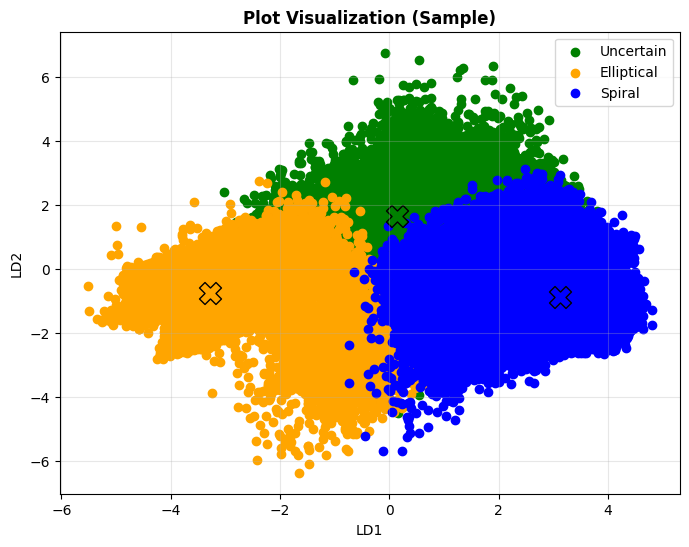

In [ ]:
# Plot sample
class_names = ['Uncertain', 'Elliptical', 'Spiral']
colors = ['green', 'orange', 'blue']

plt.figure(figsize=(8,6))

# Plot data tiap kelas
for i, class_id in enumerate(sorted(np.unique(y_final))):
    mask = y_final == class_id
    plt.scatter(
        X_lda.loc[mask].iloc[:, 0],
        X_lda.loc[mask].iloc[:, 1],
        label=class_names[i],
        color=colors[i],
        alpha=1
    )

# Hitung centroid
centroids = data.groupby('Class')[['LD1','LD2']].mean()

# Plot centroid + label
for i, class_id in enumerate(centroids.index):
    
    x = centroids.loc[class_id, 'LD1']
    y = centroids.loc[class_id, 'LD2']

    plt.scatter(
        x, y,
        color=colors[i],
        marker='X',
        s=250,
        edgecolors='black'
    )

plt.xlabel(f"LD1")
plt.ylabel(f"LD2")
plt.title("Plot Visualization (Sample)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
class LDAFuzzyMembershipMuSigma:
    def __init__(self, X):
        self.X = X
        self.n_features = X.shape[1]
        self.params = []
        self._build_membership()

    def _build_membership(self):
        for i in range(self.n_features):
            xi = self.X[:, i]

            xmin = np.min(xi)
            xmax = np.max(xi)
            mu = np.mean(xi)
            sigma = np.std(xi)

            feature_params = {
                "low":    [xmin, xmin, mu - 1*sigma, mu],
                "medium": [mu - 1*sigma, mu, mu, mu + 1*sigma],
                "high":   [mu, mu + 1*sigma, xmax, xmax]
            }

            self.params.append(feature_params)

    def trapezoidal(self, x, a, b, c, d):
        return np.maximum(
            np.minimum(
                np.minimum((x - a) / (b - a + 1e-8), 1),
                np.minimum((d - x) / (d - c + 1e-8), 1)
            ),
            0
        )

    def compute_membership(self, X_input):
        memberships = []

        for i in range(self.n_features):
            xi = X_input[:, i]
            p = self.params[i]

            low = self.trapezoidal(xi, *p["low"])
            med = self.trapezoidal(xi, *p["medium"])
            high = self.trapezoidal(xi, *p["high"])

            memberships.append(np.stack([low, med, high], axis=1))

        return np.concatenate(memberships, axis=1)
X_lda = X_lda.values
fuzzy = LDAFuzzyMembershipMuSigma(X_lda)
X_fuzzy = fuzzy.compute_membership(X_lda)

In [148]:
def plot_mu_sigma_membership(fuzzy_model, X, feature_index=0, feature_name="LD1"):
    
    params = fuzzy_model.params[feature_index]
    xi = X[:, feature_index]

    xmin = np.min(xi)
    xmax = np.max(xi)

    x_range = np.linspace(xmin, xmax, 500)

    def trap(x, a, b, c, d):
        return np.maximum(
            np.minimum(
                np.minimum((x - a) / (b - a + 1e-8), 1),
                np.minimum((d - x) / (d - c + 1e-8), 1)
            ),
            0
        )

    low = trap(x_range, *params["low"])
    med = trap(x_range, *params["medium"])
    high = trap(x_range, *params["high"])

    plt.figure(figsize=(8,5))
    plt.plot(x_range, low, label="Low", linewidth=2)
    plt.plot(x_range, med, label="Medium", linewidth=2)
    plt.plot(x_range, high, label="High", linewidth=2)
    plt.xlim([xmin,xmax])
    plt.hist(xi, bins=30, density=True, alpha=0.25)

    plt.title(f"Trapezoidal Membership - {feature_name}")
    plt.xlabel(feature_name)
    plt.ylabel("Membership Degree")
    plt.legend()
    plt.grid(True)
    plt.show()

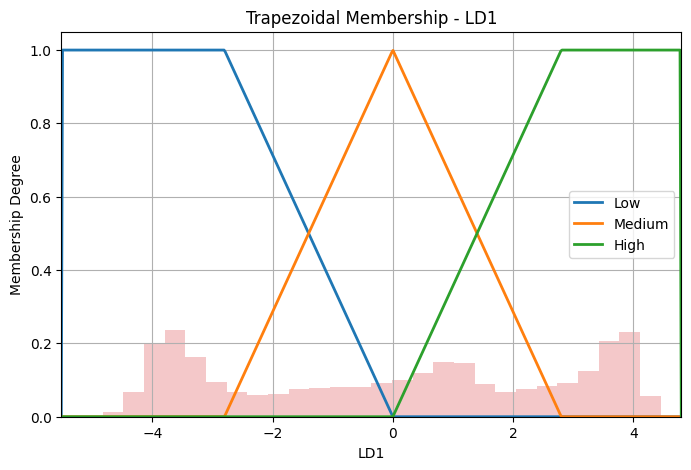

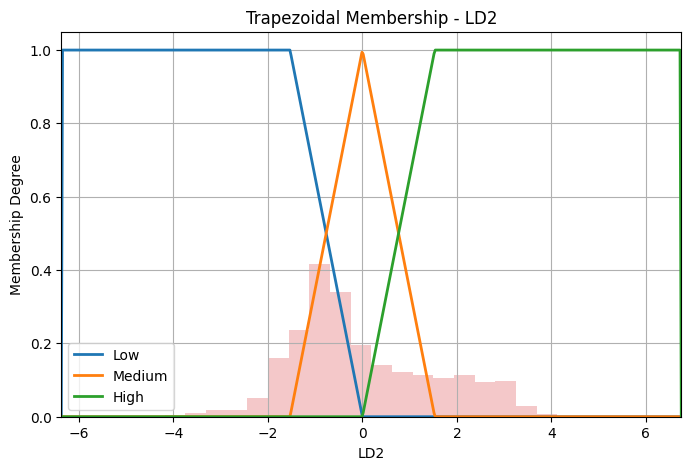

In [149]:
# Plot LD1
plot_mu_sigma_membership(fuzzy, X_lda, feature_index=0, feature_name="LD1")

# Plot LD2
plot_mu_sigma_membership(fuzzy, X_lda, feature_index=1, feature_name="LD2")

### Simulation

Train set      : 116766 samples (70.0%)
Validation set : 16664 samples (10.0%)
Test set       : 33379 samples (20.0%)
Total          : 166809 samples
Input features : 6

Indices - Train: 116766, Val: 16664, Test: 33379

MODEL ARCHITECTURE
FNNWithAttention(
  (fc1): Linear(in_features=6, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (bn3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (attention): Sequential(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (fc_out): Linear(in_features=16, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Total parameters: 3,476
T

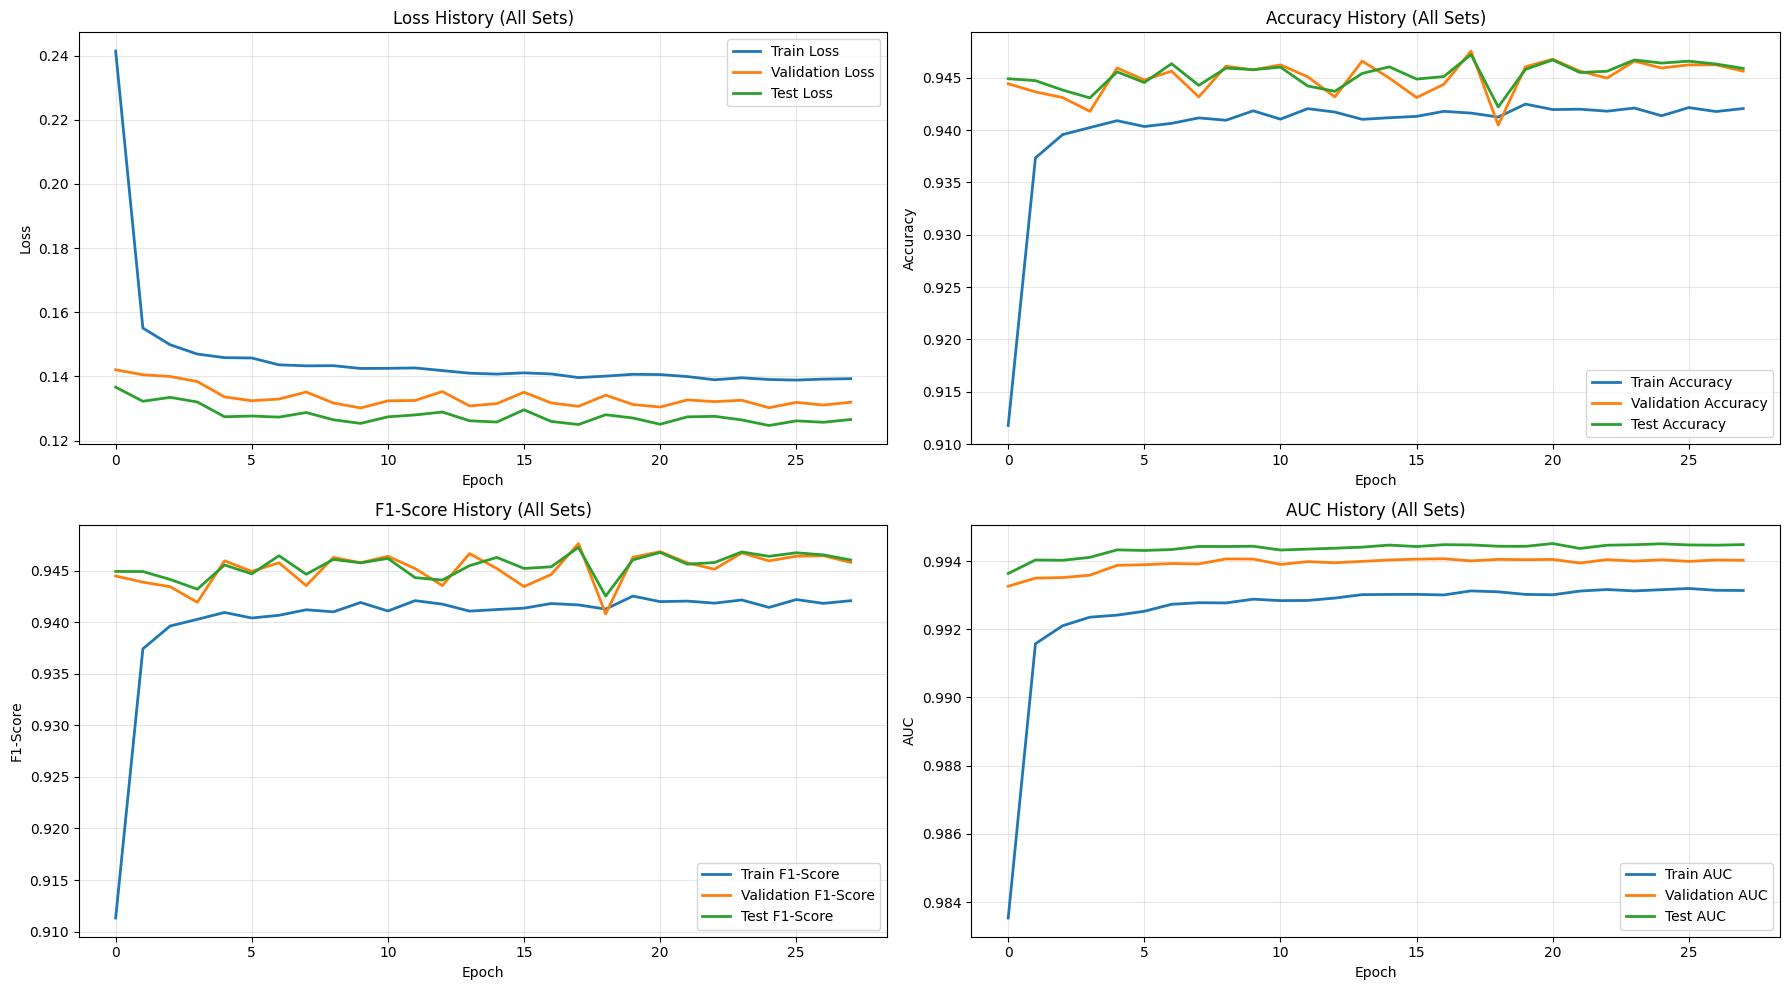


CLASSIFICATION REPORT 
              precision    recall  f1-score   support

   Uncertain     0.9112    0.9286    0.9198     11126
  Elliptical     0.9845    0.9701    0.9772     11126
      Spiral     0.9432    0.9390    0.9411     11127

    accuracy                         0.9459     33379
   macro avg     0.9463    0.9459    0.9461     33379
weighted avg     0.9463    0.9459    0.9461     33379



<Figure size 800x600 with 0 Axes>

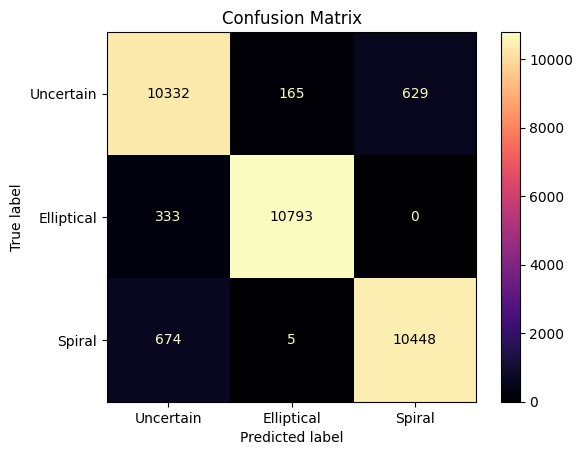


Shape X_test_lda: (33379, 2)
Shape y_test_array: (33379,)
Shape y_pred_array: (33379,)


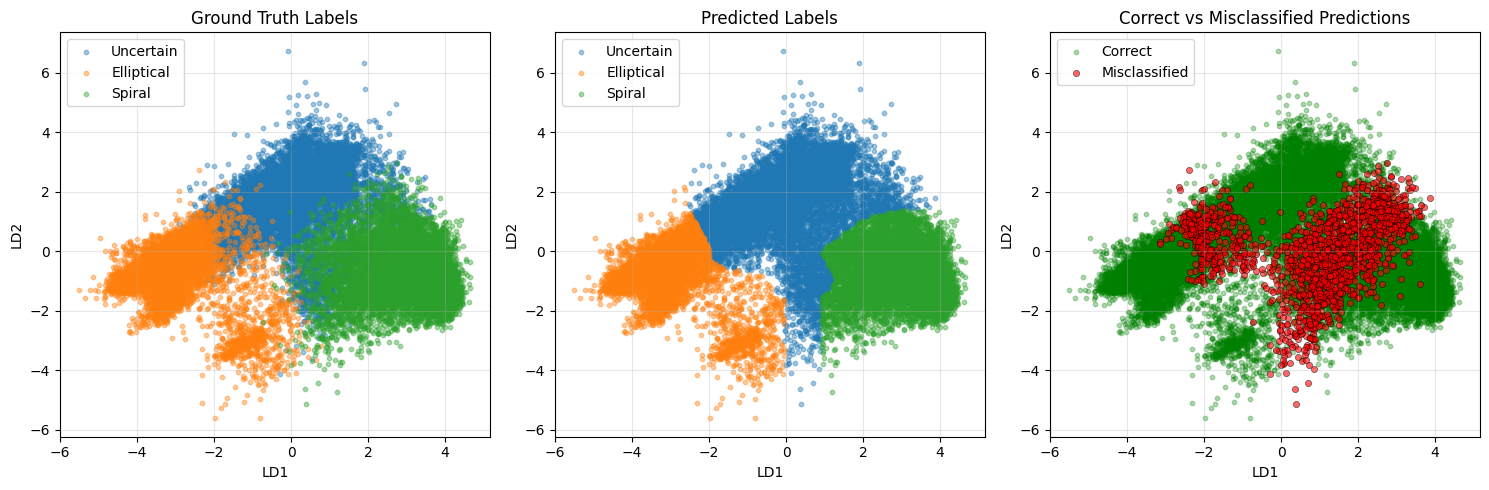

STATISTIK DETAIL
Train Loss         : 0.1393
Validation Loss    : 0.1320
Test Loss          : 0.1266
Train Accuracy     : 0.9421 (94.21%)
Train F1-Score     : 0.9421 (94.21%)
Validation Accuracy: 0.9456 (94.56%)
Validation F1-Score: 0.9458 (94.58%)
Best Validation F1 : 0.9476 (94.76%) at epoch 18
Test Accuracy      : 0.9459 (94.59%)
Test F1-Score      : 0.9461 (94.61%)
Test Precision     : 0.9463 (94.63%)
Test Recall        : 0.9459 (94.59%)

Per-class Metrics:
  Uncertain   : Precision=0.9112, Recall=0.9286, F1=0.9198
  Elliptical  : Precision=0.9845, Recall=0.9701, F1=0.9772
  Spiral      : Precision=0.9432, Recall=0.9390, F1=0.9411


In [ ]:
# Preparation Data
# Split 7-1-2
X_train, X_temp, y_train, y_temp = train_test_split(
    X_fuzzy, y_final, test_size=0.3, random_state=209, stratify=y_final
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.667, random_state=209, stratify=y_temp
)

print(f"Train set      : {X_train.shape[0]} samples ({X_train.shape[0]/len(X_fuzzy)*100:.1f}%)")
print(f"Validation set : {X_val.shape[0]} samples ({X_val.shape[0]/len(X_fuzzy)*100:.1f}%)")
print(f"Test set       : {X_test.shape[0]} samples ({X_test.shape[0]/len(X_fuzzy)*100:.1f}%)")
print(f"Total          : {len(X_fuzzy)} samples")
print(f"Input features : {X_fuzzy.shape[1]}")

# Save index for plot 
train_indices = y_train.index
val_indices = y_val.index
test_indices = y_test.index

print(f"\nIndices - Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

# Convert to tensor
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

# DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define FNN with Attention
class FNNWithAttention(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(FNNWithAttention, self).__init__()
        
        # Fully connected layers
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, 16)
        self.bn3 = nn.BatchNorm1d(16)
        
        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(16, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )
        
        # Output layer
        self.fc_out = nn.Linear(16, num_classes)
        
        # Regularization
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        # Hidden layers
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        
        # Attention weights
        attn_weights = self.attention(x)  # (batch_size, 1)
        attn_weights = F.softmax(attn_weights, dim=0)  # Normalize across batch
        
        # Apply attention (weighted features)
        x_attended = x * attn_weights
        
        # Output
        out = self.fc_out(x_attended)
        return out
# Initialization
model = FNNWithAttention(input_dim=X_fuzzy.shape[1], num_classes=3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-5)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2, eta_min=1e-5
        )

print("\n" + "=" * 60)
print("Model Architecture")
print("=" * 60)
print(model)

# Hitung jumlah parameter
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Training loop with validation
num_epochs = 50
train_losses = []
val_losses = []
test_losses = []  
train_accs = []
val_accs = []
train_f1_scores = []
val_f1_scores = []
learning_rates = []
train_aucs = []
val_aucs = []
test_aucs = []

test_accs_per_epoch = []
test_aucs_per_epoch = []
test_f1_scores_per_epoch = []
test_precision_per_epoch = []
test_recall_per_epoch = []

best_val_f1 = 0.0
best_epoch = 0
best_model_state = None
patience_counter = 0
early_stop_patience = 10

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_train_preds = []
    all_train_labels = []
    all_train_probs = []
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
      
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())
        probs = F.softmax(outputs, dim=1)
        all_train_probs.extend(probs.detach().cpu().numpy())   
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_f1 = f1_score(all_train_labels, all_train_preds, average='weighted')
    train_auc = roc_auc_score(all_train_labels, all_train_probs, multi_class='ovr', average='weighted')

    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1_scores.append(train_f1)
    train_aucs.append(train_auc)

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    all_val_preds = []
    all_val_labels = []
    all_val_probs = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())
            probs = F.softmax(outputs, dim=1)
            all_val_probs.extend(probs.detach().cpu().numpy())

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    val_f1 = f1_score(all_val_labels, all_val_preds, average='weighted')
    val_auc = roc_auc_score(all_val_labels, all_val_probs, multi_class='ovr', average='weighted')

    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1_scores.append(val_f1)
    val_aucs.append(val_auc)

    # Test phase (per epoch)
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    all_test_preds = []
    all_test_labels = []
    all_test_probs = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            all_test_preds.extend(predicted.cpu().numpy())
            all_test_labels.extend(labels.cpu().numpy())
            probs = F.softmax(outputs, dim=1)
            all_test_probs.extend(probs.detach().cpu().numpy())

    test_loss = test_loss / len(test_loader)
    test_acc = test_correct / test_total
    test_f1 = f1_score(all_test_labels, all_test_preds, average='weighted')
    test_precision = precision_score(all_test_labels, all_test_preds, average='weighted', zero_division=0)
    test_recall = recall_score(all_test_labels, all_test_preds, average='weighted', zero_division=0)
    test_auc = roc_auc_score(all_test_labels, all_test_probs, multi_class='ovr', average='weighted')

    test_losses.append(test_loss)
    test_accs_per_epoch.append(test_acc)
    test_f1_scores_per_epoch.append(test_f1)
    test_precision_per_epoch.append(test_precision)
    test_recall_per_epoch.append(test_recall)
    test_aucs_per_epoch.append(test_auc)

    # Record learning rate
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save best model based on F1-score
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= early_stop_patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break
    
    # Print progress
    if (epoch + 1) % 1 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
      f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}, Train AUC: {train_auc:.4f} | "
      f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}, Val AUC: {val_auc:.4f} | "
      f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}, Test AUC: {test_auc:.4f} | "
      f"LR: {current_lr:.2e}")

print(f"\nTraining complete! Best validation F1-score: {best_val_f1:.4f} ({best_val_f1*100:.2f}%) at epoch {best_epoch+1}")

# Load best model
model.load_state_dict(best_model_state)

# Plot metrics history
plt.figure(figsize=(18, 10))

# Plot loss
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss History (All Sets)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot accuracy
plt.subplot(2, 2, 2)
plt.plot(train_accs, label='Train Accuracy', linewidth=2)
plt.plot(val_accs, label='Validation Accuracy', linewidth=2)
plt.plot(test_accs_per_epoch, label='Test Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy History (All Sets)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot F1-score
plt.subplot(2, 2, 3)
plt.plot(train_f1_scores, label='Train F1-Score', linewidth=2)
plt.plot(val_f1_scores, label='Validation F1-Score', linewidth=2)
plt.plot(test_f1_scores_per_epoch, label='Test F1-Score', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.title('F1-Score History (All Sets)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(train_aucs, label='Train AUC', linewidth=2)
plt.plot(val_aucs, label='Validation AUC', linewidth=2)
plt.plot(test_aucs_per_epoch, label='Test AUC', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('AUC History (All Sets)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluation
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Classification report
print("\n" + "=" * 60)
print("Classification Report")
print("=" * 60)
print(classification_report(all_labels, all_preds, 
                          target_names=['Intermediate', 'Non-Spiral', 'Spiral'], digits=4))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                            display_labels=['Intermediate', 'Non-Spiral', 'Spiral'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='magma', values_format='d')
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

# Prediction Plot
X_test_lda = X_lda[test_indices]
y_test_array = y_test.values
y_pred_array = np.array(all_preds)

print(f"\nShape X_test_lda: {X_test_lda.shape}")
print(f"Shape y_test_array: {y_test_array.shape}")
print(f"Shape y_pred_array: {y_pred_array.shape}")

plt.figure(figsize=(15, 5))

# Plot 1: Ground Truth
plt.subplot(1, 3, 1)
colors = ['red', 'blue', 'green']
labels_map = ['Intermediate', 'Non-Spiral', 'Spiral']
for label in range(3):
    mask = y_test_array == label
    plt.scatter(
        X_test_lda[mask, 0],
        X_test_lda[mask, 1],
        #c=colors[label],
        label=labels_map[label],
        alpha=0.4,
        s=10
    )
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('Ground Truth Labels')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Predictions
plt.subplot(1, 3, 2)
for label in range(3):
    mask = y_pred_array == label
    plt.scatter(
        X_test_lda[mask, 0],
        X_test_lda[mask, 1],
        #c=colors[label],
        label=labels_map[label],
        alpha=0.4,
        s=10
    )
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('Predicted Labels')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Correct vs Misclassified
plt.subplot(1, 3, 3)
misclassified_mask = y_pred_array != y_test_array
plt.scatter(
    X_test_lda[~misclassified_mask, 0],
    X_test_lda[~misclassified_mask, 1],
    c='green', label='Correct', alpha=0.3, s=10
)
plt.scatter(
    X_test_lda[misclassified_mask, 0],
    X_test_lda[misclassified_mask, 1],
    c='red', label='Misclassified', alpha=0.6, s=20, edgecolors='black', linewidth=0.5
)
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('Correct vs Misclassified Predictions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 60)
print("Results")
print("=" * 60)
print(f"Train Loss         : {train_losses[-1]:.4f}")
print(f"Validation Loss    : {val_losses[-1]:.4f}")
print(f"Test Loss          : {test_losses[-1]:.4f}")
print(f"Train Accuracy     : {train_accs[-1]:.4f} ({train_accs[-1]*100:.2f}%)")
print(f"Train F1-Score     : {train_f1_scores[-1]:.4f} ({train_f1_scores[-1]*100:.2f}%)")
print(f"Validation Accuracy: {val_accs[-1]:.4f} ({val_accs[-1]*100:.2f}%)")
print(f"Validation F1-Score: {val_f1_scores[-1]:.4f} ({val_f1_scores[-1]*100:.2f}%)")
print(f"Best Validation F1 : {best_val_f1:.4f} ({best_val_f1*100:.2f}%) at epoch {best_epoch+1}")
print(f"Test Accuracy      : {accuracy_score(all_labels, all_preds):.4f} ({accuracy_score(all_labels, all_preds)*100:.2f}%)")
print(f"Test F1-Score      : {f1_score(all_labels, all_preds, average='weighted'):.4f} ({f1_score(all_labels, all_preds, average='weighted')*100:.2f}%)")
print(f"Test Precision     : {precision_score(all_labels, all_preds, average='weighted'):.4f} ({precision_score(all_labels, all_preds, average='weighted')*100:.2f}%)")
print(f"Test Recall        : {recall_score(all_labels, all_preds, average='weighted'):.4f} ({recall_score(all_labels, all_preds, average='weighted')*100:.2f}%)")

# Per-class metrics
print("\nPer-class Metrics:")
for i, label in enumerate(['Intermediate', 'Non-Spiral', 'Spiral']):
    precision = precision_score(all_labels, all_preds, labels=[i], average=None)[0]
    recall = recall_score(all_labels, all_preds, labels=[i], average=None)[0]
    f1 = f1_score(all_labels, all_preds, labels=[i], average=None)[0]
    print(f"  {label:12s}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

In [151]:
best_test_accuracy = max(test_accs_per_epoch)
best_val_accuracy = max(val_accs)
print(f"Best Test Accuracy: {best_test_accuracy:.4f}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Test AUC          : {test_aucs_per_epoch[-1]:.4f}")
print(f"Validation AUC          : {val_aucs[-1]:.4f}")

Best Test Accuracy: 0.9472
Best Validation Accuracy: 0.9476
Test AUC          : 0.9945
Validation AUC          : 0.9940


<Figure size 800x600 with 0 Axes>

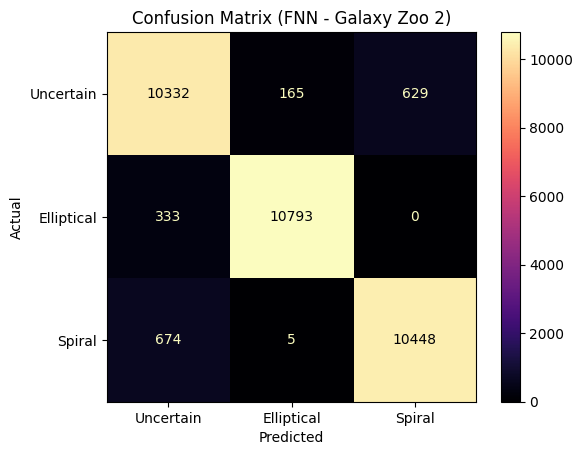

In [152]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=['Uncertain', 'Elliptical', 'Spiral'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='magma', values_format='d')
plt.title('Confusion Matrix (FNN - Galaxy Zoo 2)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.grid(False)
plt.show()

In [153]:
hasil_lda = pd.DataFrame(data=X_test_lda, columns=["LD1", "LD2"])
hasil_lda["Class"] = y_pred_array
#hasil_lda.to_csv("hasil_gz2_under.csv", index=False)

In [154]:
hasil_centroids = hasil_lda.groupby('Class')[['LD1', 'LD2']].mean()

# Display centroids
print(hasil_centroids)

            LD1       LD2
Class                    
0      0.119171  1.624139
1     -3.315622 -0.768472
2      3.187276 -0.895077


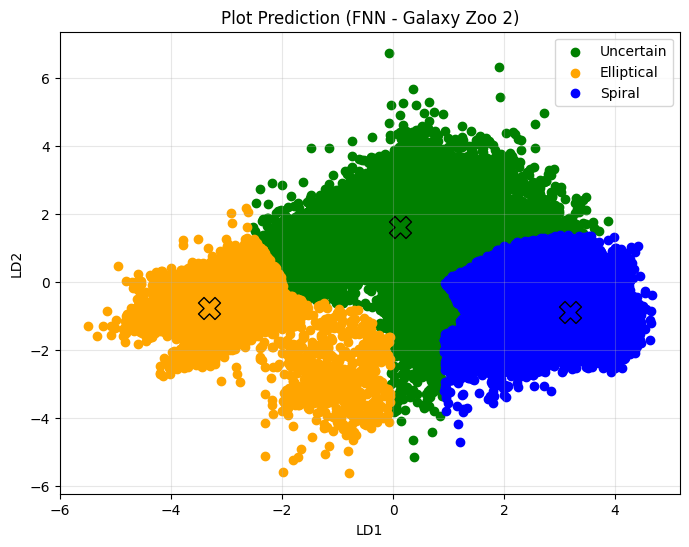

In [168]:
class_names = ['Uncertain', 'Elliptical', 'Spiral']
colors = ['green', 'orange', 'blue']

plt.figure(figsize=(8,6))

# Plot data tiap kelas
for label in range(3):
    mask = y_pred_array == label
    plt.scatter(
        X_test_lda[mask, 0],
        X_test_lda[mask, 1],
        c=colors[label],
        label=class_names[label]
    )

# Hitung centroid
centroids = hasil_lda.groupby('Class')[['LD1','LD2']].mean()

# Plot centroid + label
for i, class_id in enumerate(centroids.index):
    
    x = centroids.loc[class_id, 'LD1']
    y = centroids.loc[class_id, 'LD2']

    plt.scatter(
        x, y,
        color=colors[i],
        marker='X',
        s=250,
        edgecolors='black'
    )

plt.xlabel(f"LD1")
plt.ylabel(f"LD2")
plt.title("Plot Prediction (FNN - Galaxy Zoo 2)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()